Loaded upgrade_cohort: (15684, 79)
  risky_upgrade (comparison) : 1,308  (8.3%)
  safe_upgrade  (control)    : 14,376  (91.7%)
  Post-upgrade default rate  : 8.34%

Financial features available for analysis: 64

[Section 1] Cohort overview


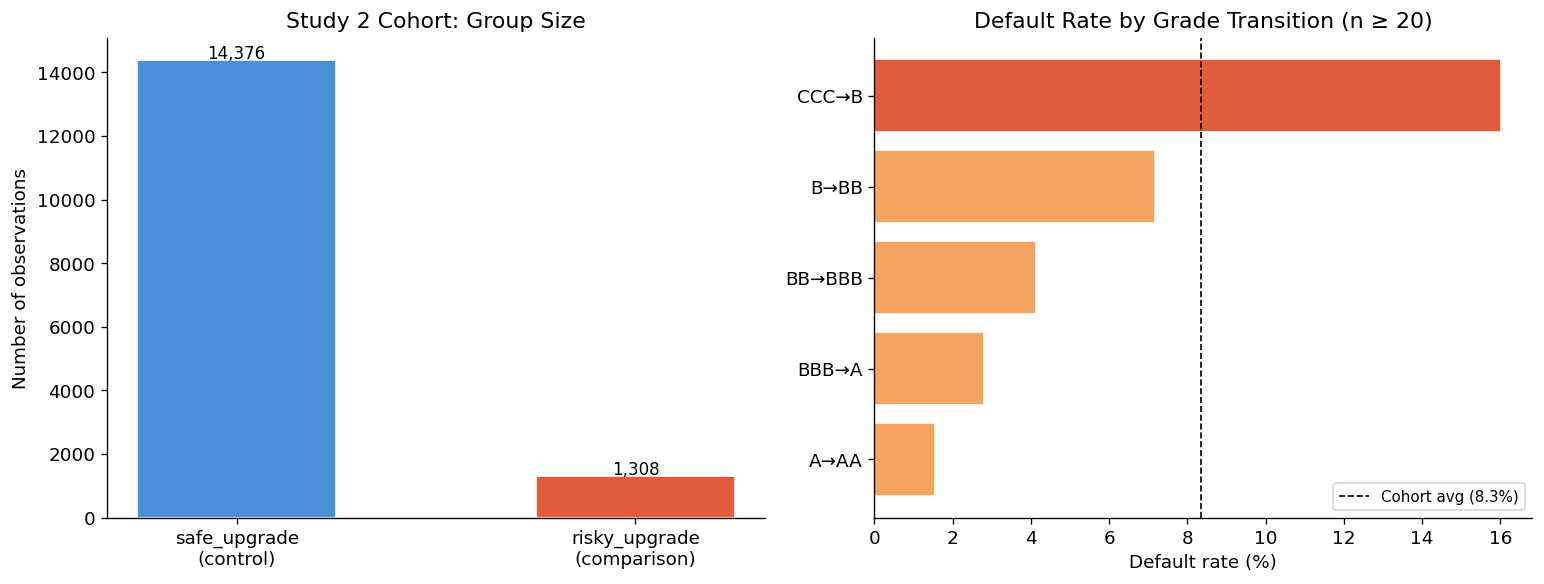

Figure saved: NB02_01_cohort_overview.png

[Section 2] Descriptive statistics
Saved: ../results/tables/NB02_01_descriptive_stats.csv

Top 10 features by absolute mean difference (risky - safe):
                             risky_mean  safe_mean  mean_diff
feature                                                      
Attr55                       -1295.3884  1321.9329 -2617.3213
Attr15                        1725.7188  2129.3354  -403.6166
cash_to_current_liabilities   -107.0014   -32.0544   -74.9470
Attr32                         194.4830   137.0100    57.4730
Attr62                         190.5288   133.4719    57.0569
Attr27                          16.7709    33.2177   -16.4468
Attr43                         127.8512   119.4129     8.4383
Attr44                          69.4259    64.0073     5.4186
Attr47                          50.8471    54.4705    -3.6235
Attr20                          54.8360    52.7830     2.0530

[Section 3] Mann-Whitney U test (risky vs safe)
Saved: ../res

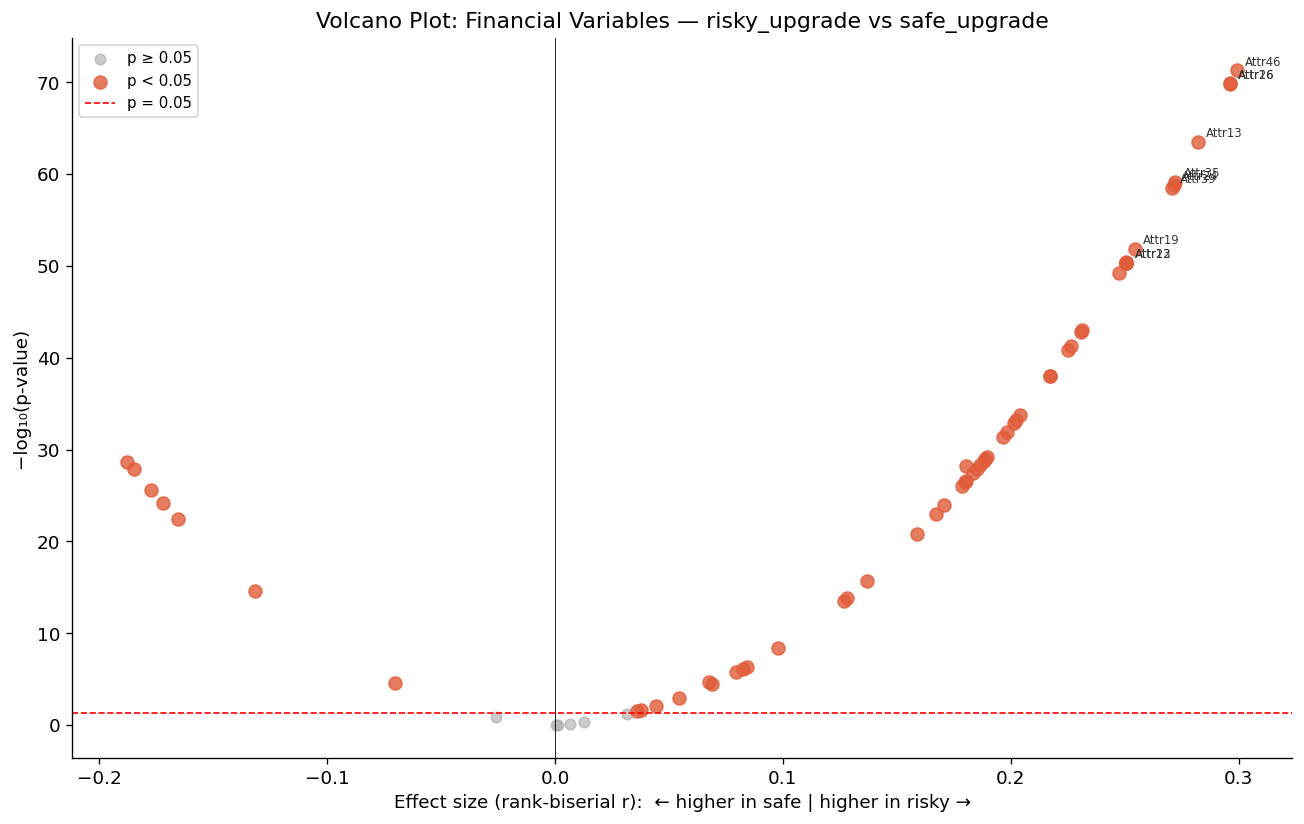

Figure saved: NB02_02_volcano_plot.png

[Section 5] Box plots — top 20 significant variables


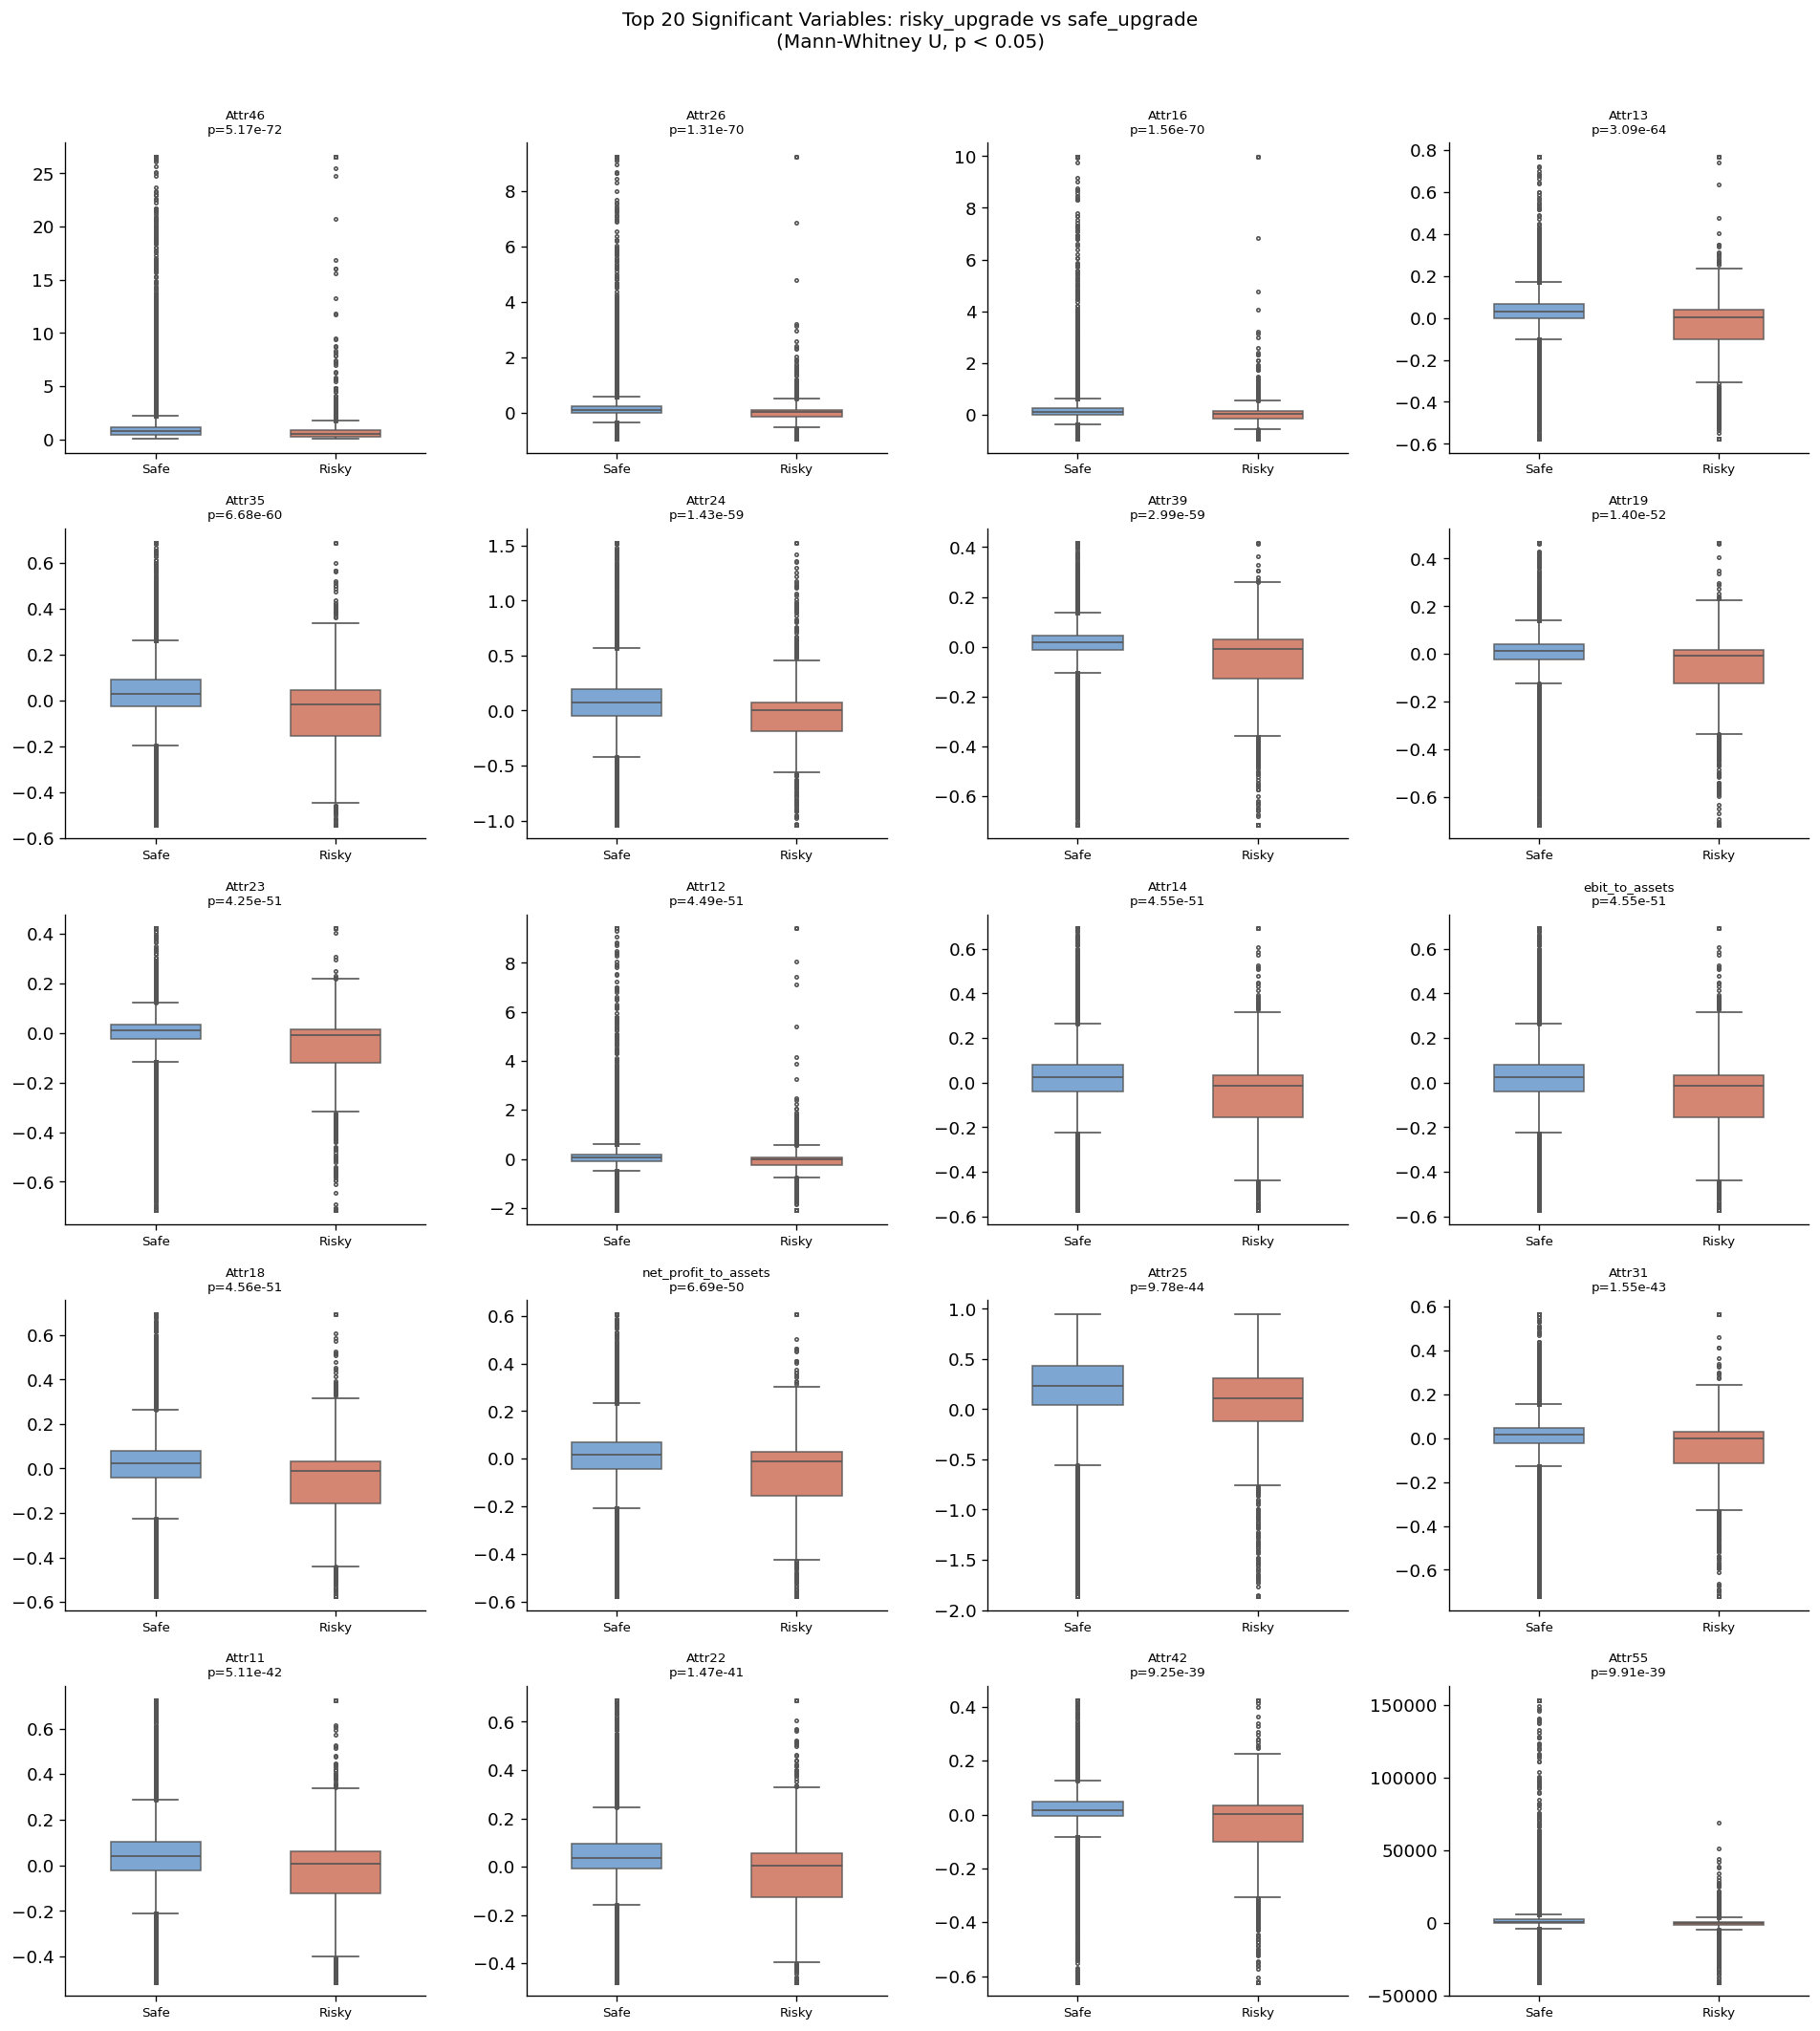

Figure saved: NB02_03_boxplots_top20.png

[Section 6] Distribution histograms — top 6 variables


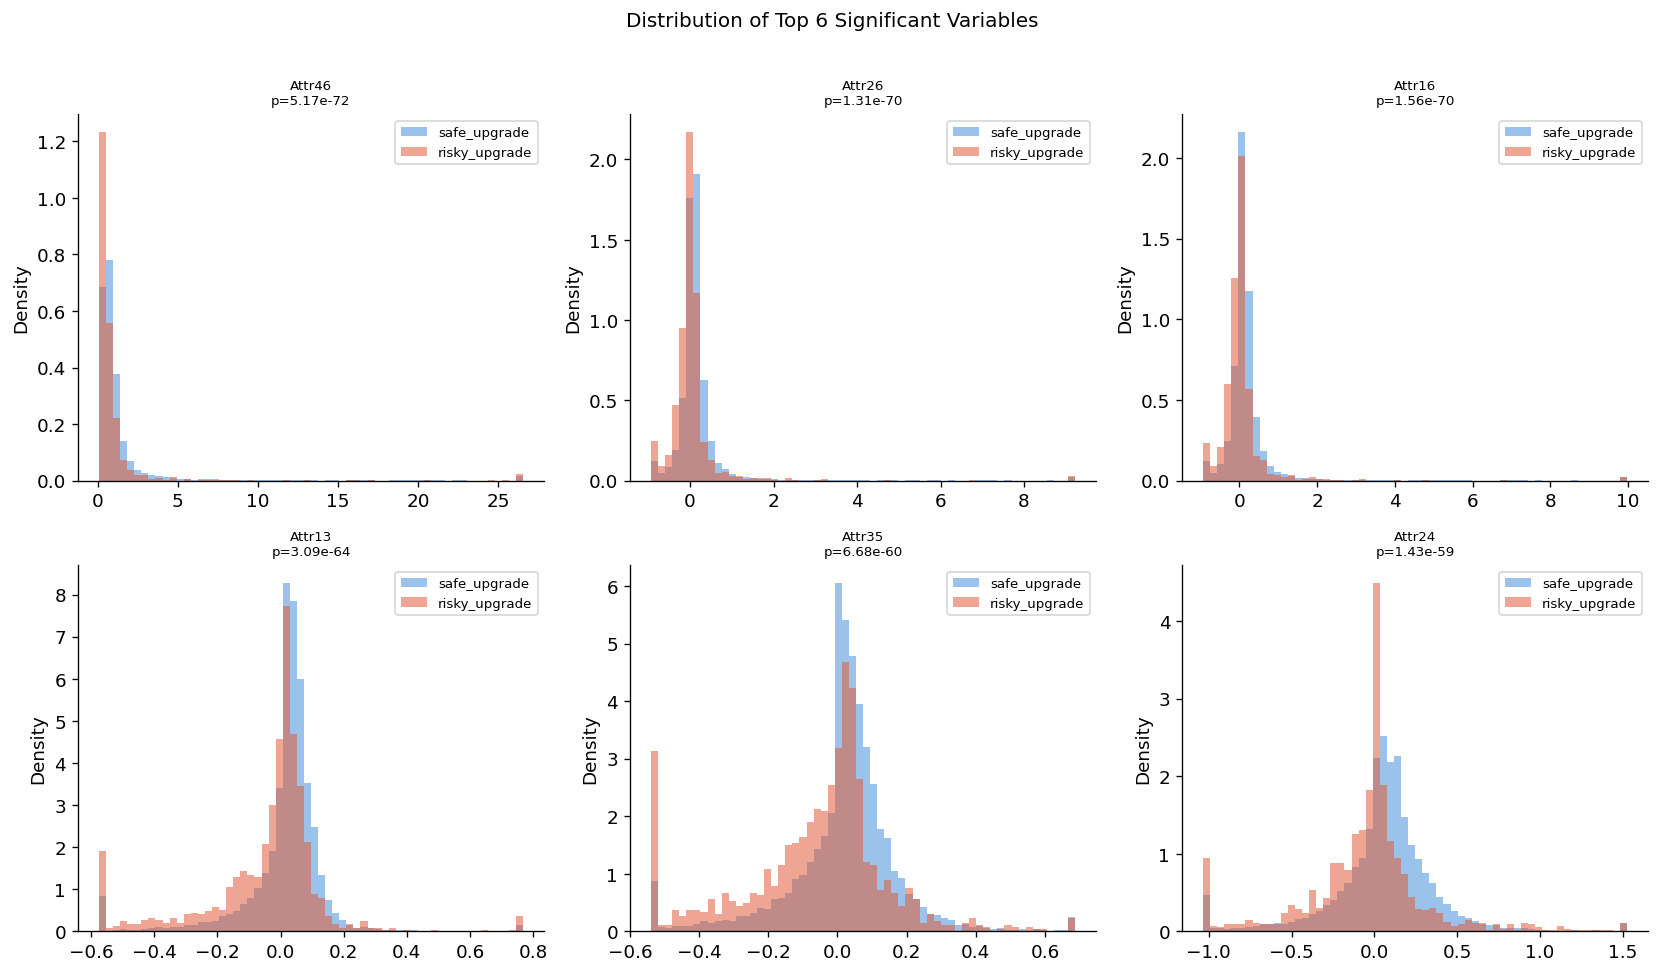

Figure saved: NB02_04_histograms_top6.png

[Section 7] Correlation heatmap — significant variables


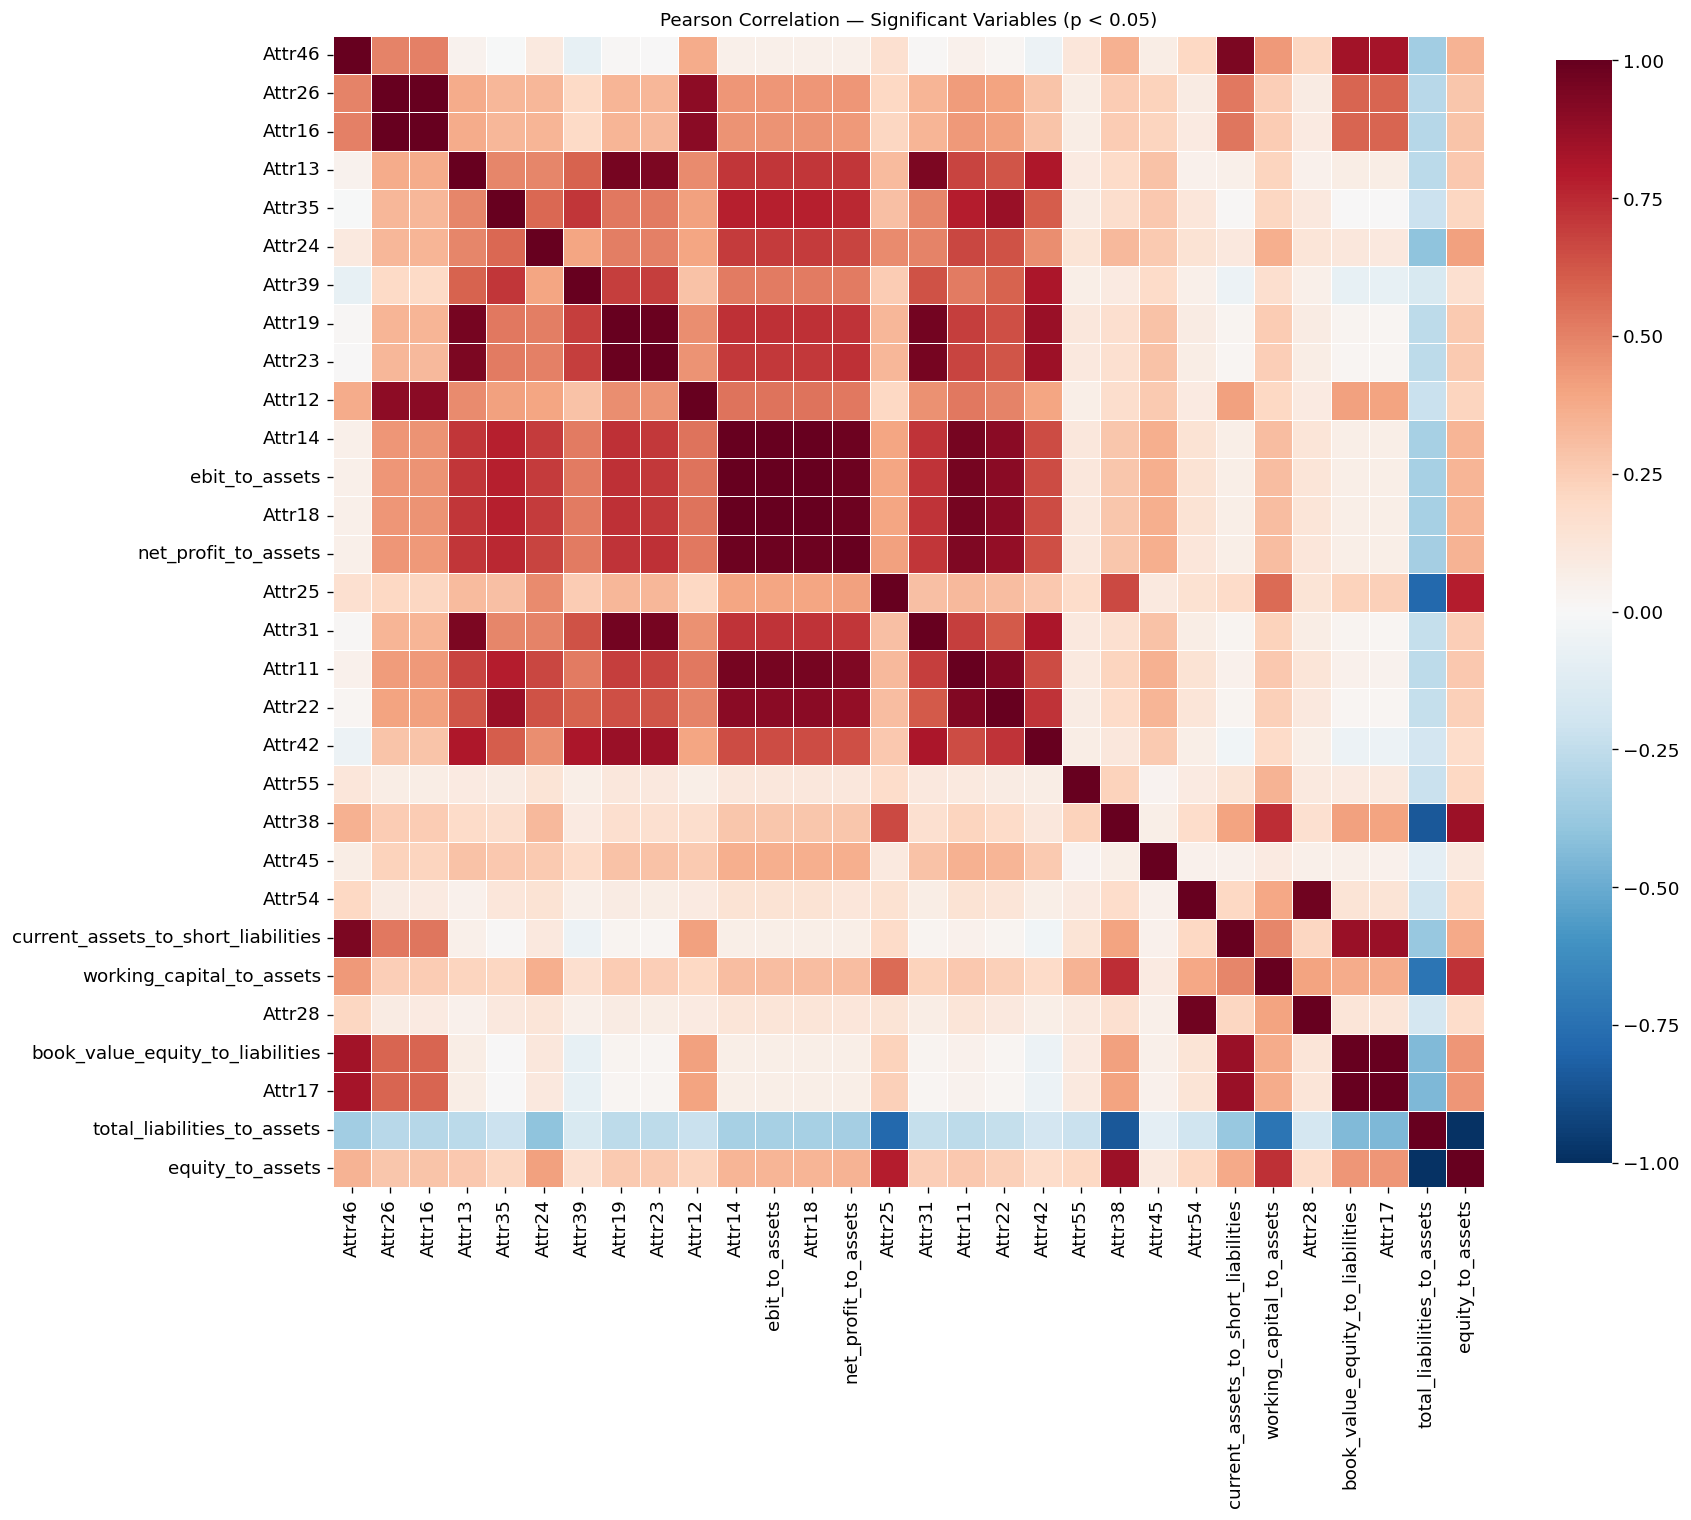

Figure saved: NB02_05_correlation_heatmap.png

NB02 SUMMARY
Total financial variables tested : 64
Significant at p < 0.05          : 58
Significant at p < 0.01          : 56
Significant at p < 0.001         : 54

Top 10 candidate variables for NB03 (univariate logistic regression):
   1. Attr46                                         p=5.17e-72
   2. Attr26                                         p=1.31e-70
   3. Attr16                                         p=1.56e-70
   4. Attr13                                         p=3.09e-64
   5. Attr35                                         p=6.68e-60
   6. Attr24                                         p=1.43e-59
   7. Attr39                                         p=2.99e-59
   8. Attr19                                         p=1.40e-52
   9. Attr23                                         p=4.25e-51
  10. Attr12                                         p=4.49e-51

Significant variable list saved to:
  ../results/tables/NB02_02_mannwhitney_

In [1]:
# NB02_eda.ipynb
# Study 2: Comparing financial characteristics between risky and safe upgrade groups
#
# Input  : data/processed/upgrade_cohort.parquet  (produced by NB01)
# Outputs:
#   results/figures/NB02_*.png
#   results/tables/NB02_01_descriptive_stats.csv
#   results/tables/NB02_02_mannwhitney_results.csv  — significant variables → NB03 input

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.dpi"       : 120,
    "axes.spines.top"  : False,
    "axes.spines.right": False,
    "font.size"        : 11,
})

PROC_DIR  = "../data/processed/"
FIG_DIR   = "../results/figures/"
TABLE_DIR = "../results/tables/"

os.makedirs(FIG_DIR,   exist_ok=True)
os.makedirs(TABLE_DIR, exist_ok=True)

# ── Load upgrade cohort ───────────────────────────────────────────────────────

cohort = pd.read_parquet(PROC_DIR + "upgrade_cohort.parquet")

risky = cohort[cohort["group"] == "risky_upgrade"]
safe  = cohort[cohort["group"] == "safe_upgrade"]

print(f"Loaded upgrade_cohort: {cohort.shape}")
print(f"  risky_upgrade (comparison) : {len(risky):,}  ({len(risky)/len(cohort)*100:.1f}%)")
print(f"  safe_upgrade  (control)    : {len(safe):,}  ({len(safe)/len(cohort)*100:.1f}%)")
print(f"  Post-upgrade default rate  : {cohort['default'].mean()*100:.2f}%")

# Financial feature columns (exclude non-financial metadata)
EXCLUDE = {
    "default", "year_horizon", "class", "pd_system",
    "grade_ordinal", "grade_diff", "override_flag", "final_grade_ordinal",
    "system_grade", "group", "is_risky",
    "from_grade", "to_grade", "transition", "high_risk_transition",
}
fin_cols = [c for c in cohort.columns if c not in EXCLUDE
            and cohort[c].dtype in [np.float64, np.int64, float, int]]

print(f"\nFinancial features available for analysis: {len(fin_cols)}")


# ── 1. Cohort overview — group size and default rate by grade transition ──────

print("\n[Section 1] Cohort overview")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel A: group counts
group_counts = cohort["group"].value_counts()
colors = {"risky_upgrade": "#E05C3A", "safe_upgrade": "#4A90D9"}
axes[0].bar(
    ["safe_upgrade\n(control)", "risky_upgrade\n(comparison)"],
    [group_counts.get("safe_upgrade", 0), group_counts.get("risky_upgrade", 0)],
    color=["#4A90D9", "#E05C3A"],
    width=0.5, edgecolor="white",
)
axes[0].set_title("Study 2 Cohort: Group Size")
axes[0].set_ylabel("Number of observations")
for bar in axes[0].patches:
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 50,
        f"{int(bar.get_height()):,}",
        ha="center", fontsize=10,
    )

# Panel B: default rate by grade transition
trans_dr = (
    cohort.groupby("transition")["default"]
    .agg(["mean", "count"])
    .query("count >= 20")
    .sort_values("mean", ascending=True)
)
trans_dr["mean_pct"] = trans_dr["mean"] * 100
bar_colors = ["#E05C3A" if v > cohort["default"].mean() * 100
              else "#F4A460" for v in trans_dr["mean_pct"]]
axes[1].barh(trans_dr.index, trans_dr["mean_pct"],
             color=bar_colors, edgecolor="white")
axes[1].axvline(cohort["default"].mean() * 100,
                color="black", linestyle="--", linewidth=1,
                label=f"Cohort avg ({cohort['default'].mean()*100:.1f}%)")
axes[1].set_title("Default Rate by Grade Transition (n ≥ 20)")
axes[1].set_xlabel("Default rate (%)")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig(FIG_DIR + "NB02_01_cohort_overview.png", bbox_inches="tight")
plt.show()
print("Figure saved: NB02_01_cohort_overview.png")


# ── 2. Descriptive statistics — risky vs safe ─────────────────────────────────

print("\n[Section 2] Descriptive statistics")

desc_rows = []
for col in fin_cols:
    r_vals = risky[col].dropna()
    s_vals = safe[col].dropna()
    desc_rows.append({
        "feature"        : col,
        "risky_mean"     : r_vals.mean(),
        "risky_median"   : r_vals.median(),
        "risky_std"      : r_vals.std(),
        "safe_mean"      : s_vals.mean(),
        "safe_median"    : s_vals.median(),
        "safe_std"       : s_vals.std(),
        "mean_diff"      : r_vals.mean() - s_vals.mean(),
        "median_diff"    : r_vals.median() - s_vals.median(),
    })

desc_df = pd.DataFrame(desc_rows).set_index("feature").round(4)
desc_df["abs_mean_diff"] = desc_df["mean_diff"].abs()
desc_df_sorted = desc_df.sort_values("abs_mean_diff", ascending=False)

out_path = TABLE_DIR + "NB02_01_descriptive_stats.csv"
desc_df_sorted.to_csv(out_path)
print(f"Saved: {out_path}")
print(f"\nTop 10 features by absolute mean difference (risky - safe):")
print(desc_df_sorted[["risky_mean", "safe_mean", "mean_diff"]].head(10).to_string())


# ── 3. Mann-Whitney U test — all financial variables ─────────────────────────

print("\n[Section 3] Mann-Whitney U test (risky vs safe)")

mw_rows = []
for col in fin_cols:
    r_vals = risky[col].dropna()
    s_vals = safe[col].dropna()
    if len(r_vals) < 5 or len(s_vals) < 5:
        continue
    stat, pval = stats.mannwhitneyu(r_vals, s_vals, alternative="two-sided")
    mw_rows.append({
        "feature"  : col,
        "U_stat"   : stat,
        "p_value"  : pval,
        "sig_05"   : pval < 0.05,
        "sig_01"   : pval < 0.01,
        "sig_001"  : pval < 0.001,
    })

mw_df = pd.DataFrame(mw_rows).set_index("feature").sort_values("p_value")

# Merge with descriptive stats for context
mw_df = mw_df.join(desc_df[["risky_median", "safe_median", "median_diff"]])

out_path = TABLE_DIR + "NB02_02_mannwhitney_results.csv"
mw_df.to_csv(out_path)
print(f"Saved: {out_path}")

sig_vars = mw_df[mw_df["sig_05"]].index.tolist()
print(f"\nSignificant variables (p < 0.05) : {len(sig_vars)} / {len(mw_df)}")
print(f"Significant variables (p < 0.01) : {mw_df['sig_01'].sum()}")
print(f"Significant variables (p < 0.001): {mw_df['sig_001'].sum()}")
print(f"\nTop 15 most significant variables:")
print(mw_df[["p_value", "risky_median", "safe_median", "median_diff"]].head(15).to_string())


# ── 4. Volcano plot — effect size vs significance ────────────────────────────

print("\n[Section 4] Volcano plot")

# Compute rank-biserial correlation as effect size (r = 1 - 2U / (n1*n2))
mw_df["n_risky"] = len(risky)
mw_df["n_safe"]  = len(safe)
mw_df["effect_r"] = 1 - 2 * mw_df["U_stat"] / (mw_df["n_risky"] * mw_df["n_safe"])
mw_df["neg_log10_p"] = -np.log10(mw_df["p_value"].clip(lower=1e-300))

fig, ax = plt.subplots(figsize=(11, 7))

# Non-significant
mask_ns = ~mw_df["sig_05"]
ax.scatter(mw_df.loc[mask_ns, "effect_r"],
           mw_df.loc[mask_ns, "neg_log10_p"],
           color="#AAAAAA", alpha=0.6, s=40, label="p ≥ 0.05")

# Significant
mask_s = mw_df["sig_05"]
ax.scatter(mw_df.loc[mask_s, "effect_r"],
           mw_df.loc[mask_s, "neg_log10_p"],
           color="#E05C3A", alpha=0.8, s=60, label="p < 0.05")

# Label top 10 significant variables
top10 = mw_df[mask_s].nlargest(10, "neg_log10_p")
for feat, row in top10.iterrows():
    ax.annotate(feat.replace("_", "\n"),
                xy=(row["effect_r"], row["neg_log10_p"]),
                xytext=(5, 3), textcoords="offset points",
                fontsize=7, color="#333333")

ax.axhline(-np.log10(0.05), color="red", linestyle="--", linewidth=1,
           label="p = 0.05")
ax.axvline(0, color="black", linestyle="-", linewidth=0.5)
ax.set_xlabel("Effect size (rank-biserial r):  ← higher in safe | higher in risky →")
ax.set_ylabel("−log₁₀(p-value)")
ax.set_title("Volcano Plot: Financial Variables — risky_upgrade vs safe_upgrade")
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(FIG_DIR + "NB02_02_volcano_plot.png", bbox_inches="tight")
plt.show()
print("Figure saved: NB02_02_volcano_plot.png")


# ── 5. Box plots — top 20 significant variables ───────────────────────────────

print("\n[Section 5] Box plots — top 20 significant variables")

top20 = mw_df[mw_df["sig_05"]].head(20).index.tolist()

if len(top20) == 0:
    print("No significant variables found. Skipping box plots.")
else:
    n_cols = 4
    n_rows = int(np.ceil(len(top20) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(n_cols * 4, n_rows * 3.5))
    axes = axes.flatten()

    plot_data = cohort[cohort["group"].isin(["risky_upgrade", "safe_upgrade"])].copy()

    for ax, col in zip(axes, top20):
        sns.boxplot(
            data=plot_data, x="group", y=col, ax=ax,
            order=["safe_upgrade", "risky_upgrade"],
            palette={"safe_upgrade": "#4A90D9", "risky_upgrade": "#E05C3A"},
            width=0.5, fliersize=2,
            boxprops=dict(alpha=0.8),
        )
        p_val  = mw_df.loc[col, "p_value"]
        p_label = (f"p={p_val:.3f}" if p_val >= 0.001
                   else f"p={p_val:.2e}")
        ax.set_title(f"{col}\n{p_label}", fontsize=8)
        ax.set_xlabel("")
        ax.set_xticklabels(["Safe", "Risky"], fontsize=8)
        ax.set_ylabel("")

    # Hide unused axes
    for ax in axes[len(top20):]:
        ax.set_visible(False)

    plt.suptitle("Top 20 Significant Variables: risky_upgrade vs safe_upgrade\n"
                 "(Mann-Whitney U, p < 0.05)",
                 fontsize=12, y=1.01)
    plt.tight_layout()
    plt.savefig(FIG_DIR + "NB02_03_boxplots_top20.png", bbox_inches="tight")
    plt.show()
    print("Figure saved: NB02_03_boxplots_top20.png")


# ── 6. Distribution histograms — top 6 variables ─────────────────────────────

print("\n[Section 6] Distribution histograms — top 6 variables")

top6 = mw_df[mw_df["sig_05"]].head(6).index.tolist()

if len(top6) > 0:
    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    axes = axes.flatten()

    for ax, col in zip(axes, top6):
        ax.hist(safe[col].dropna(), bins=60, alpha=0.55,
                color="#4A90D9", label="safe_upgrade", density=True)
        ax.hist(risky[col].dropna(), bins=60, alpha=0.55,
                color="#E05C3A", label="risky_upgrade", density=True)
        p_val   = mw_df.loc[col, "p_value"]
        p_label = f"p={p_val:.3f}" if p_val >= 0.001 else f"p={p_val:.2e}"
        ax.set_title(f"{col}\n{p_label}", fontsize=8)
        ax.legend(fontsize=8)
        ax.set_ylabel("Density")

    plt.suptitle("Distribution of Top 6 Significant Variables",
                 fontsize=12, y=1.01)
    plt.tight_layout()
    plt.savefig(FIG_DIR + "NB02_04_histograms_top6.png", bbox_inches="tight")
    plt.show()
    print("Figure saved: NB02_04_histograms_top6.png")


# ── 7. Correlation heatmap — significant variables only ───────────────────────

print("\n[Section 7] Correlation heatmap — significant variables")

if len(sig_vars) >= 2:
    corr_vars = sig_vars[:30]   # cap at 30 for readability
    corr      = cohort[corr_vars].corr()

    fig, ax = plt.subplots(figsize=(max(10, len(corr_vars) * 0.5),
                                    max(8,  len(corr_vars) * 0.5)))
    sns.heatmap(
        corr, ax=ax,
        cmap="RdBu_r", center=0, vmin=-1, vmax=1,
        linewidths=0.3, square=True,
        cbar_kws={"shrink": 0.7},
        annot=len(corr_vars) <= 15,
        fmt=".2f", annot_kws={"size": 7},
    )
    ax.set_title("Pearson Correlation — Significant Variables (p < 0.05)",
                 fontsize=11)
    plt.tight_layout()
    plt.savefig(FIG_DIR + "NB02_05_correlation_heatmap.png", bbox_inches="tight")
    plt.show()
    print("Figure saved: NB02_05_correlation_heatmap.png")


# ── 8. Summary and handoff to NB03 ────────────────────────────────────────────

print("\n" + "=" * 60)
print("NB02 SUMMARY")
print("=" * 60)
print(f"Total financial variables tested : {len(mw_df)}")
print(f"Significant at p < 0.05          : {len(sig_vars)}")
print(f"Significant at p < 0.01          : {int(mw_df['sig_01'].sum())}")
print(f"Significant at p < 0.001         : {int(mw_df['sig_001'].sum())}")
print()
print("Top 10 candidate variables for NB03 (univariate logistic regression):")
for i, feat in enumerate(mw_df[mw_df["sig_05"]].head(10).index, 1):
    row    = mw_df.loc[feat]
    p_str  = f"{row['p_value']:.4f}" if row['p_value'] >= 0.0001 else f"{row['p_value']:.2e}"
    print(f"  {i:2d}. {feat:<45s}  p={p_str}")
print()
print(f"Significant variable list saved to:")
print(f"  {TABLE_DIR}NB02_02_mannwhitney_results.csv")
print()
print("Next step → NB03_univariate_logistic.py")